# Phase 8 - Advanced Transformer Concepts

> **Transformer Mastery - Phase Notebook**

## Objective
Explore the engineering ideas that make modern Transformers faster, more memory-efficient, and more scalable: KV caching, RoPE, Flash Attention as an algorithmic idea, Mixture-of-Experts, and scaling laws.

### Notebook standard
- Reproducible setup
- Concepts → implementation → experiment → interpretation
- Explicit sanity checks
- Visual diagnostics
- Practical takeaways
- Limitations clearly stated

## 1. Setup

In [1]:
import math, random, re, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

SEED = 32
random.seed(SEED)
np.random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cpu
Device: cpu


## 2. KV Cache — Why Autoregressive Generation Gets Expensive

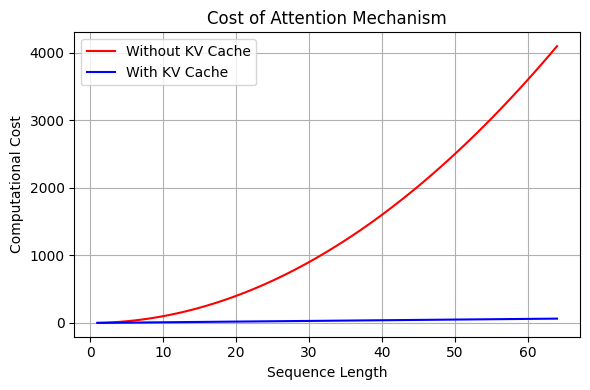

In [2]:
# Conceptual cost comparison.
# Without a cache, every generation step recomputes keys/values for all previous tokens.
# With a KV cache, previous K/V tensors are reused.

seq_lengths   = np.arange(1, 65)
without_cache = seq_lengths * seq_lengths
with_cache    = seq_lengths * 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(seq_lengths, without_cache, label="Without KV Cache", color="red")
ax.plot(seq_lengths, with_cache, label="With KV Cache", color="blue")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Computational Cost")
ax.set_title("Cost of Attention Mechanism")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## 3. Rotary Position Embeddings (RoPE)

In [3]:
def rotate_half(x):
    x1 , x2 = x[..., ::2], x[..., 1::2]
    return torch.stack(
        (-x2, x1),
        dim=-1
    ).flatten(-2)

def rope(x, base=10000):
    # x: [batch, heads, seq, dim]
    B, H, T, D = x.shape
    assert D % 2 == 0, "Dimension must be even for RoPE."
    pos      = torch.arange(T, device=x.device, dtype=torch.float32)
    inv_freq = 1.0 / (base ** (torch.arange(0, D, 2, device=x.device, dtype=torch.float32) / D))
    angles   = torch.outer(pos, inv_freq)
    sin, cos = angles.sin(), angles.cos()
    sin, cos = sin[None, None, :, :], cos[None, None, :, :]

    even_odd = x.reshape(B, H, T, D // 2, 2)
    a, b     = even_odd[..., 0], even_odd[..., 1]
    rotated  = torch.stack([a * cos - b * sin, a * sin + b * cos], dim=-1)
    return rotated.reshape(B, H, T, D)

x = torch.randn(1, 2, 16, 32)
y = rope(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

assert x.shape == y.shape, "RoPE output shape must match input shape."



Input shape : torch.Size([1, 2, 16, 32])
Output shape: torch.Size([1, 2, 16, 32])


## 4. Visualize a RoPE Rotation

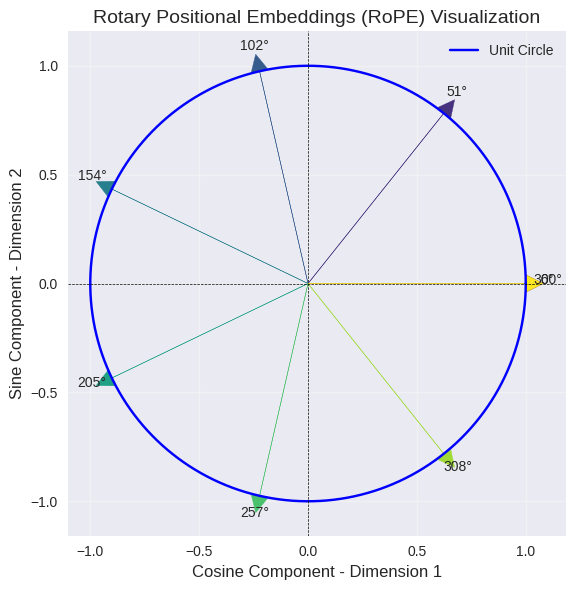

In [4]:
angles = np.linspace(0, 2*np.pi, 200)
x1, x2 = np.cos(angles), np.sin(angles)

plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x1, x2, label="Unit Circle", color="blue")
ax.set_aspect('equal', 'box')
ax.set_xlabel("Cosine Component - Dimension 1", fontsize=12)
ax.set_ylabel("Sine Component - Dimension 2", fontsize=12)
ax.set_title("Rotary Positional Embeddings (RoPE) Visualization", fontsize=14)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.axvline(0, color='black', lw=0.5, ls='--')
ax.grid(alpha=0.3)

# Draw arrows for multiple angles with color gradient
sample_angles = np.linspace(0, 2*np.pi, 8)  # 8 arrows
colors = plt.cm.viridis(np.linspace(0, 1, len(sample_angles)))
for angle, c in zip(sample_angles, colors):
    x, y = np.cos(angle), np.sin(angle)
    ax.arrow(0, 0, x, y, head_width=0.08, head_length=0.08, fc=c, ec=c)
    ax.text(x*1.1, y*1.1, f"{int(np.degrees(angle))}°", fontsize=10, ha='center')

ax.legend()
plt.tight_layout()
plt.show()


## 5. Flash Attention — The Core Idea

Flash Attention is not simply "a faster softmax." The central engineering idea is to compute attention in a memory-aware, tiled manner so the implementation avoids materializing the full attention matrix in high-bandwidth memory.

Conceptually:

**Q/K/V → tiled computation → online softmax → output**

This reduces memory traffic and can substantially improve GPU efficiency. The exact implementation depends on the hardware and kernel.

In [5]:
def naive_attention_memory(T, bytes_per_element=2):
    # Approximate memory just for an explicit T x T attention matrix.
    return T*T*bytes_per_element / (1024**2)

for T in [512, 1024, 2048, 4096, 8192]:
    print(f"T={T:5d} -> explicit attention matrix ≈ {naive_attention_memory(T):8.1f} MiB")

T=  512 -> explicit attention matrix ≈      0.5 MiB
T= 1024 -> explicit attention matrix ≈      2.0 MiB
T= 2048 -> explicit attention matrix ≈      8.0 MiB
T= 4096 -> explicit attention matrix ≈     32.0 MiB
T= 8192 -> explicit attention matrix ≈    128.0 MiB


## 6. Mixture-of-Experts (MoE)

In [6]:
class TinyMoE(nn.Module):
    def __init__(self, d_model=32, experts=4):
        super().__init__()
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, 4*d_model),
                nn.GELU(),
                nn.Linear(4*d_model, d_model)
            ) for _ in range(experts)
        ])
        self.router  = nn.Linear(d_model, experts)


    def forward(self, x):
        # x: [batch, seq, d_model]
        gates = self.router(x).softmax(-1)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=-1)
        # [B,S,D,E] weighted combination
        out   = (expert_outputs * gates.unsqueeze(-2)).sum(-1)
        return out, gates

moe = TinyMoE().to(DEVICE)
x   = torch.randn(2, 8, 32).to(DEVICE)
out, gates = moe(x)

print("Input shape :", x.shape)
print("Output shape:", out.shape)
print("Gates shape :", gates.shape)
print("\nGates (softmax probabilities):\n")
print(gates)
print("\nAverage routing probabilities:", gates.mean(dim=(0,1)).detach().cpu().numpy())

Input shape : torch.Size([2, 8, 32])
Output shape: torch.Size([2, 8, 32])
Gates shape : torch.Size([2, 8, 4])

Gates (softmax probabilities):

tensor([[[0.1104, 0.3544, 0.3797, 0.1555],
         [0.1985, 0.2128, 0.4244, 0.1643],
         [0.1288, 0.2509, 0.3979, 0.2225],
         [0.0737, 0.6231, 0.0912, 0.2120],
         [0.1655, 0.2146, 0.4207, 0.1992],
         [0.1929, 0.2981, 0.1816, 0.3273],
         [0.3265, 0.2867, 0.2351, 0.1517],
         [0.5212, 0.1986, 0.1934, 0.0868]],

        [[0.3159, 0.2896, 0.1654, 0.2291],
         [0.1486, 0.0993, 0.3055, 0.4466],
         [0.0606, 0.6371, 0.1470, 0.1553],
         [0.3523, 0.1029, 0.1452, 0.3996],
         [0.2083, 0.1870, 0.2991, 0.3055],
         [0.2656, 0.1614, 0.3783, 0.1947],
         [0.1253, 0.4844, 0.2306, 0.1597],
         [0.2850, 0.1845, 0.2367, 0.2938]]], grad_fn=<SoftmaxBackward0>)

Average routing probabilities: [0.21744673 0.28658625 0.26449245 0.23147452]


## 7. Scaling-Law Thought Experiment

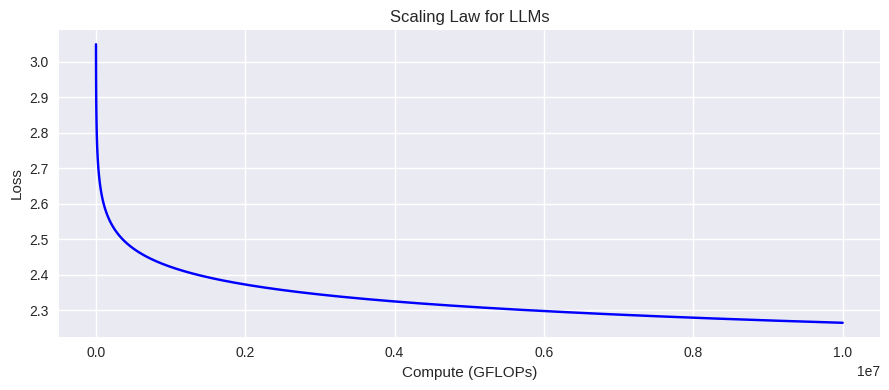

In [7]:
# A toy empirical relationship: loss tends to decrease as model/data/compute scale.
# This is illustrative, NOT a fitted law for real LLMs.

compute  = np.logspace(3, 7, 100)
toy_loss = 2.8 * compute**(-0.06) + 1.2

fig, ax  = plt.subplots(figsize=(9, 4))
ax.plot(compute, toy_loss, color="blue")
ax.set_xlabel("Compute (GFLOPs)")
ax.set_ylabel("Loss")
ax.set_title("Scaling Law for LLMs")
ax.grid(True)
plt.tight_layout()
plt.show()

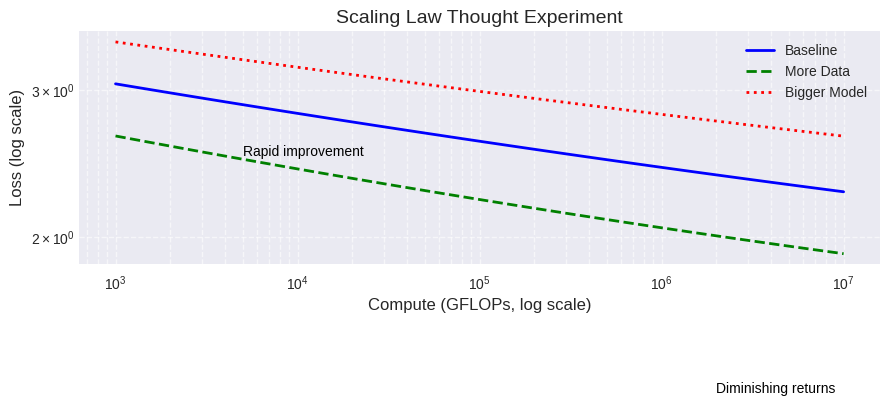

In [8]:
compute = np.logspace(3, 7, 100)

# Toy scaling laws for different regimes
loss_base   = 2.8 * compute**(-0.06) + 1.2
loss_data   = 2.5 * compute**(-0.07) + 1.1   # more data
loss_model  = 3.0 * compute**(-0.05) + 1.3   # larger model

plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(compute, loss_base,  label="Baseline", color="blue", lw=2)
ax.plot(compute, loss_data,  label="More Data", color="green", lw=2, ls="--")
ax.plot(compute, loss_model, label="Bigger Model", color="red", lw=2, ls=":")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute (GFLOPs, log scale)", fontsize=12)
ax.set_ylabel("Loss (log scale)", fontsize=12)
ax.set_title("Scaling Law Thought Experiment", fontsize=14)

# Annotate diminishing returns
ax.text(2e6, 1.3, "Diminishing returns", fontsize=10, color="black")
ax.text(5e3, 2.5, "Rapid improvement", fontsize=10, color="black")

ax.grid(True, which="both", ls="--", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()


## 8. Engineering Trade-Off Table

| Technique | Main problem addressed | Main idea |
|---|---|---|
| KV Cache | Repeated generation computation | Reuse past K/V |
| RoPE | Position representation | Rotate Q/K by position-dependent angles |
| Flash Attention | Memory traffic / attention efficiency | Tiled, IO-aware attention |
| MoE | Parameter capacity vs compute | Activate only selected experts |
| Scaling laws | Predicting useful scale | Study loss vs model/data/compute scale |

### Phase 8 takeaway

Modern Transformer expertise is not just knowing the vanilla architecture. It means understanding **where the computational and memory bottlenecks appear and which design changes address them**.